In [1]:
import sys
sys.path.append("..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import xgboost as xgb

In [2]:

X_train = np.load("../outputs/X_train.npy")
X_val   = np.load("../outputs/X_val.npy")
X_test  = np.load("../outputs/X_test.npy")
y_train = np.load("../outputs/y_train.npy", allow_pickle=True)
y_val   = np.load("../outputs/y_val.npy",   allow_pickle=True)
y_test  = np.load("../outputs/y_test.npy",  allow_pickle=True)
le = joblib.load("../outputs/models/label_encoder.pkl")
feature_cols = pd.read_csv("../outputs/feature_cols.csv").squeeze().tolist()

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")

Train: (3297, 15) | Val: (291, 15) | Test: (292, 15)
Classes: [0 1 2 3 4 5 6]


In [3]:
# Random Forest baseline

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

rf_val_preds = rf.predict(X_val)
print("=== Random Forest — Validation ===")
print(classification_report(y_val, rf_val_preds))

joblib.dump(rf, "../outputs/models/random_forest.pkl")

=== Random Forest — Validation ===
              precision    recall  f1-score   support

           0       0.60      0.67      0.63        60
           1       0.60      0.38      0.46         8
           2       0.98      0.93      0.96        59
           3       0.73      0.71      0.72       101
           4       0.48      0.54      0.51        24
           5       1.00      0.82      0.90        11
           6       0.90      0.93      0.91        28

    accuracy                           0.75       291
   macro avg       0.76      0.71      0.73       291
weighted avg       0.76      0.75      0.75       291



['../outputs/models/random_forest.pkl']

In [4]:
# XGBoost

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_preds = xgb_model.predict(X_val)
print("=== XGBoost — Validation ===")
print(classification_report(y_val, rf_val_preds, target_names=le.classes_))

joblib.dump(xgb_model, "../outputs/models/xgboost.pkl")

=== XGBoost — Validation ===
              precision    recall  f1-score   support

       Bumps       0.60      0.67      0.63        60
   Dirtiness       0.60      0.38      0.46         8
   K_Scratch       0.98      0.93      0.96        59
Other_Faults       0.73      0.71      0.72       101
      Pastry       0.48      0.54      0.51        24
      Stains       1.00      0.82      0.90        11
   Z_Scratch       0.90      0.93      0.91        28

    accuracy                           0.75       291
   macro avg       0.76      0.71      0.73       291
weighted avg       0.76      0.75      0.75       291



['../outputs/models/xgboost.pkl']

In [5]:
# Compare the two on validation
from sklearn.metrics import accuracy_score

rf_acc  = accuracy_score(y_val, rf_val_preds)
xgb_acc = accuracy_score(y_val, xgb_val_preds)

print(f"Random Forest accuracy:  {rf_acc:.4f}")
print(f"XGBoost accuracy:        {xgb_acc:.4f}")
print(f"\nBest model: {'XGBoost' if xgb_acc >= rf_acc else 'Random Forest'}")

best_model     = xgb_model if xgb_acc >= rf_acc else rf
best_val_preds = xgb_val_preds if xgb_acc >= rf_acc else rf_val_preds

Random Forest accuracy:  0.7491
XGBoost accuracy:        0.7869

Best model: XGBoost


In [6]:
# Evaluate best model on test set

test_preds = best_model.predict(X_test)

print("=== Best Model — Test Set ===")
print(classification_report(y_test, test_preds))


=== Best Model — Test Set ===
              precision    recall  f1-score   support

           0       0.72      0.72      0.72        60
           1       0.86      0.75      0.80         8
           2       1.00      0.90      0.95        59
           3       0.73      0.76      0.75       101
           4       0.56      0.62      0.59        24
           5       0.85      1.00      0.92        11
           6       1.00      0.93      0.96        29

    accuracy                           0.79       292
   macro avg       0.82      0.81      0.81       292
weighted avg       0.80      0.79      0.80       292



XGBoost outperformed Random Forest on the validation set (78.7% vs 74.9%) and achieved 79% accuracy on the held-out test set, with a weighted F1 of 0.80.


Classes with distinct physical signatures performed best. K_Scratch and Z_Scratch both reached F1 scores above 0.95, and Stains achieved perfect recall. This is consistent with the exploration findings: these classes have measurable feature signals that separate them from the rest.


The hardest class was Pastry (F1 0.59), which the model regularly confused with Other_Faults. This is expected: Other_Faults is a residual category containing defects that nearly qualified as other types, and Pastry sits at that boundary. Bumps and Other_Faults also bled into each other (F1 0.72 and 0.75 respectively) for the same reason.

Dirtiness performed reasonably despite having only 55 training samples, which suggests the features do carry some signal for that class even at low volume.

Overall the model demonstrates that tree-based methods with SMOTE balancing can reliably categorize steel surface defects from geometric and luminosity features, with the strongest performance on classes that have a consistent measurable profile and the weakest on ambiguous boundary categories.

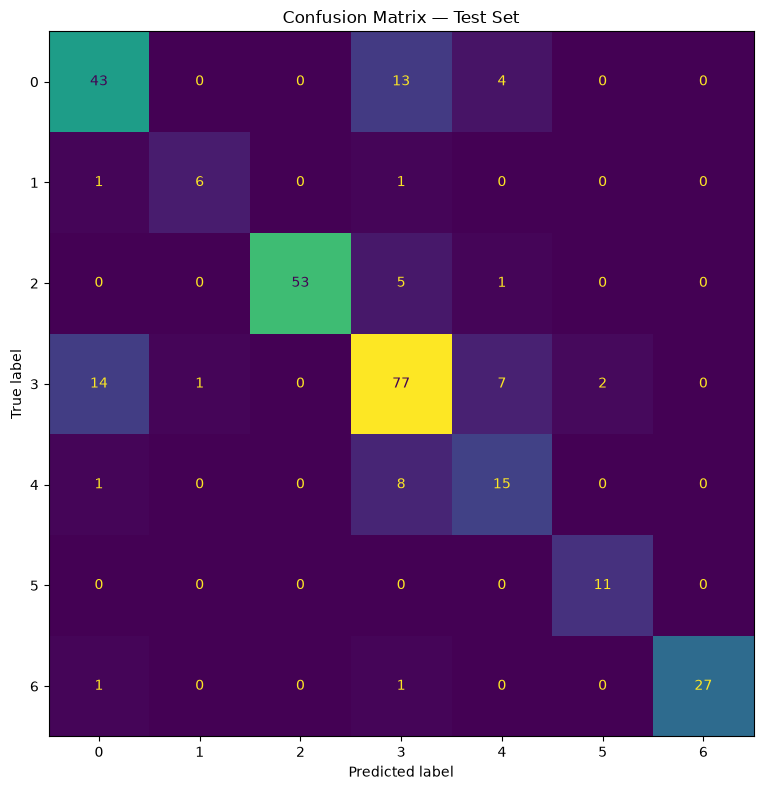

In [7]:
# Confusion matrix

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_preds,
    ax=ax,
    colorbar=False
)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrix.png", dpi=150)
plt.show()

The model struggles where the fault definition is ambiguous. Other_Faults leaks into Bumps and Pastry because it contains plates that almost qualified as those classes. Pastry leaks into Other_Faults for the same reason. Classes with distinct physical signatures, K_Scratch (large log-size), Stains (luminosity), and Z_Scratch (directional geometry), are all clean. Dirtiness is the only weak class explained purely by data scarcity rather than feature overlap.

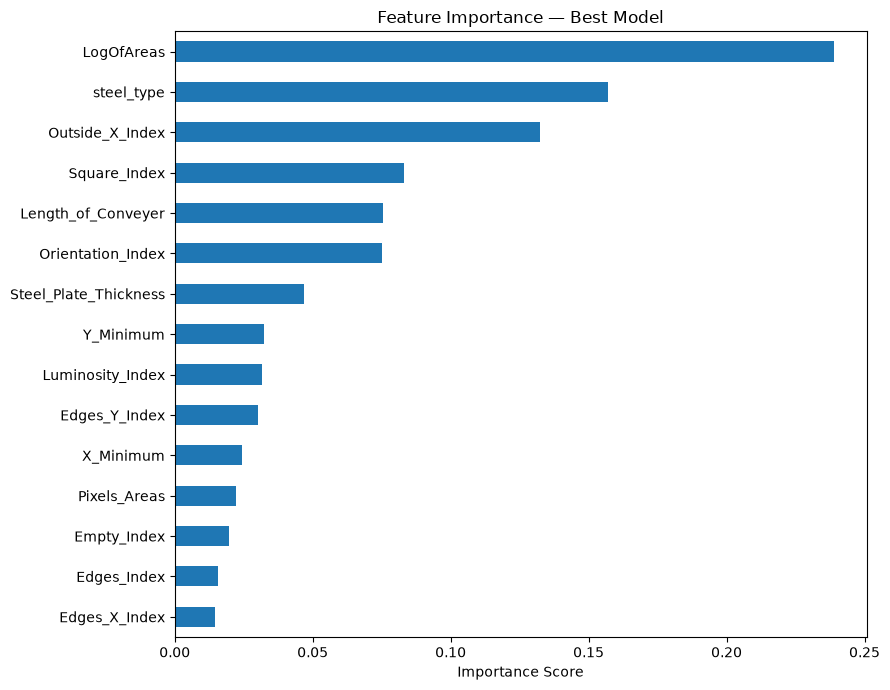

In [8]:
# Feature importance

if best_model == xgb_model:
    importances = pd.Series(xgb_model.feature_importances_, index=feature_cols)
else:
    importances = pd.Series(rf.feature_importances_, index=feature_cols)

importances = importances.sort_values(ascending=True)

importances.plot(
    kind="barh",
    figsize=(9, 7),
    title="Feature Importance — Best Model"
)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../outputs/figures/feature_importance.png", dpi=150)
plt.show()

LogOfAreas dominates with an importance score of 0.24, confirming that defect size is the primary signal the model uses to separate fault types. This is consistent with the heatmap finding that K_Scratch, the most separable class, correlates most
strongly with log-size features.


The second most important feature is steel_type at 0.16. This is supplementary data joined to the inspection records rather than a defect measurement itself. Its high rank suggests that certain fault types occur preferentially on one steel grade over the other, meaning the material specification carries diagnostic value alongside the defect geometry.


Outside_X_Index ranks third, indicating that the lateral position of a defect relative to the plate edge is meaningfully predictive. Length_of_Conveyer also ranks in the middle tier, reflecting where on the production line the defect formed. Both are contextual variables rather than pure defect measurements, and their importance highlights that fault categorization benefits from process context, not just defect geometry alone.


The lower-ranked features (luminosity, edge density, raw position) contribute individually but none is decisive on its own. The model is combining all of them to handle the classes that do not separate on size alone.